# Rock-Paper-Scissors (CNN + data augmentation)

Ce projet construit un modèle de vision par ordinateur basé sur un CNN pour reconnaître rock, paper ou scissors à partir d’images de mains.

Le pipeline complet est :
dataset → prétraitement → data augmentation → CNN → entraînement → validation → sauvegarde → prédiction


## 1- Imports + chemins + seed

On importe les outils nécessaires au projet : TensorFlow pour créer le modèle d’IA, NumPy pour manipuler les données, et Matplotlib pour afficher les images et graphiques.
Ces bibliothèques sont la base de la plupart des projets de deep learning en Python.
Sans elles, on ne peut ni construire le modèle ni visualiser les résultats.
Cette cellule prépare simplement l’environnement de travail.

In [1]:
import os
from pathlib import Path
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
# print("Data dir:", DATA_DIR)

TensorFlow: 2.20.0


## 2- Télécharger les zip (local : requests)

Cette cellule télécharge le dataset Rock-Paper-Scissors depuis Internet.
Les fichiers ZIP sont récupérés depuis les serveurs de Google (storage.googleapis.com).
Ils contiennent les images utilisées pour entraîner et tester le modèle.
On télécharge deux archives : une pour l’entraînement et une pour la validation.
Cela permet de récupérer automatiquement les données nécessaires au projet.

In [2]:
import requests

def download(url: str, dest: Path):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print("Already exists:", dest.name)
        return
    # print("Downloading:", url)
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
    # print("Saved to:", dest)

rps_zip = DATA_DIR / "rps.zip"
rps_test_zip = DATA_DIR / "rps-test-set.zip"

download("https://storage.googleapis.com/learning-datasets/rps.zip", rps_zip)
download("https://storage.googleapis.com/learning-datasets/rps-test-set.zip", rps_test_zip)

Already exists: rps.zip
Already exists: rps-test-set.zip


## 3- Extraire les zips

Les images du dataset sont chargées automatiquement depuis les dossiers rock, paper et scissors.
TensorFlow comprend que chaque dossier représente une classe.
Il crée donc deux datasets : un pour entraîner le modèle et un pour le tester.
Cela permet d’évaluer si le modèle apprend vraiment ou s’il mémorise simplement les images.

In [29]:
def unzip(zip_path: Path, extract_to: Path):
    extract_to.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    # print("Extracted:", zip_path.name, "→", extract_to)

unzip(rps_zip, DATA_DIR)
unzip(rps_test_zip, DATA_DIR)

TRAIN_DIR = DATA_DIR / "rps"
VAL_DIR   = DATA_DIR / "rps-test-set"

# TRAIN_DIR, VAL_DIR

## 4- Vérifier la structure + compter les images

On affiche les noms des classes détectées dans le dataset.
Cela permet de vérifier que TensorFlow a bien reconnu les catégories d’images.
Dans ce projet, on doit voir : rock, paper, scissors.
C’est une étape de vérification simple mais importante.

In [4]:
classes = ["rock", "paper", "scissors"]

for c in classes:
    n = len(list((TRAIN_DIR / c).glob("*")))
    print(f"train {c}: {n}")

for c in classes:
    n = len(list((VAL_DIR / c).glob("*")))
    print(f"val   {c}: {n}")

train rock: 840
train paper: 840
train scissors: 840
val   rock: 124
val   paper: 124
val   scissors: 124


## 5- Visualiser quelques images

On affiche quelques images du dataset avec leurs labels.
Cela permet de vérifier que les images sont bien chargées et correctement classées.
C’est aussi utile pour comprendre ce que le modèle va apprendre.
En machine learning, regarder les données est toujours une bonne pratique.

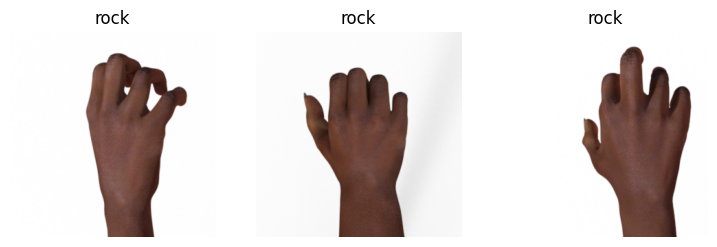

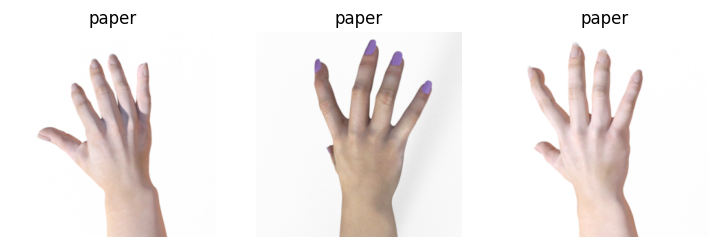

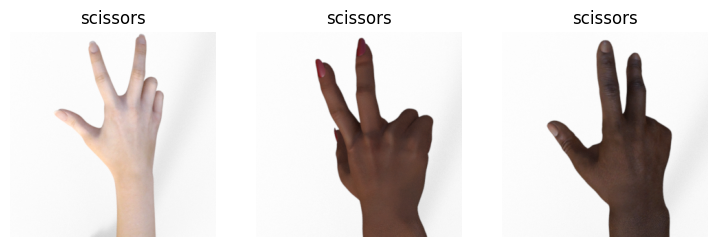

In [5]:
import random
from PIL import Image

def show_samples(folder: Path, label: str, k=3):
    paths = list(folder.glob("*"))
    picks = random.sample(paths, k)
    plt.figure(figsize=(9, 3))
    for i, p in enumerate(picks, 1):
        img = Image.open(p)
        plt.subplot(1, k, i)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.show()

for c in classes:
    show_samples(TRAIN_DIR / c, c, k=3)

## 6- Créer les datasets

Les images sont converties dans un format adapté pour le modèle (datasets TensorFlow).
On organise les données en batches pour accélérer l’entraînement.
Chaque batch contient un petit groupe d’images.
Cela permet au modèle d’apprendre plus efficacement et d’utiliser mieux le GPU.

In [6]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",   # one-hot (3 classes)
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2520 files belonging to 3 classes.
Found 372 files belonging to 3 classes.
Class names: ['paper', 'rock', 'scissors']


## 7- Normalisation + data augmentation

On applique des transformations aléatoires aux images : rotation, zoom, flip, translation.
Cela crée artificiellement de nouvelles variations d’images.
Le but est d’éviter que le modèle mémorise seulement les images du dataset.
On normalise aussi les pixels entre 0 et 1 pour stabiliser l’apprentissage.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

normalizer = tf.keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

## 8- Construire le modèle CNN

On crée le modèle d’intelligence artificielle avec plusieurs couches de convolution.
Les couches convolutionnelles détectent des motifs dans les images (bords, formes, doigts).
Les couches finales prennent ces informations et décident si l’image est rock, paper ou scissors.
Cette architecture est typique des modèles de vision par ordinateur.

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    normalizer,

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

## 9- Compile (loss/optimizer)

On configure comment le modèle va apprendre.
On choisit l’algorithme d’optimisation (RMSprop), la fonction d’erreur (categorical_crossentropy) et la métrique (accuracy).
La fonction de perte mesure l’erreur du modèle.
L’optimiseur ajuste les poids du réseau pour réduire cette erreur.

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 10- Entraîner (avec callbacks)

Le modèle est entraîné sur les images pendant plusieurs epochs.
À chaque epoch, il voit toutes les images et améliore progressivement ses prédictions.
On utilise aussi des callbacks pour sauvegarder le meilleur modèle et arrêter l’entraînement si nécessaire.
C’est l’étape où le réseau apprend réellement.

In [10]:
from pathlib import Path
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
best_path = MODELS_DIR / "rps.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 417ms/step - accuracy: 0.4103 - loss: 1.0757 - val_accuracy: 0.5806 - val_loss: 0.9955
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.5567 - loss: 0.9228 - val_accuracy: 0.7419 - val_loss: 0.6976
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 478ms/step - accuracy: 0.6889 - loss: 0.7102 - val_accuracy: 0.8306 - val_loss: 0.4759
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 541ms/step - accuracy: 0.7758 - loss: 0.5402 - val_accuracy: 0.8978 - val_loss: 0.3170
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 592ms/step - accuracy: 0.8282 - loss: 0.4211 - val_accuracy: 0.9704 - val_loss: 0.2534
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 561ms/step - accuracy: 0.8563 - loss: 0.3658 - val_accuracy: 0.9435 - val_loss: 0.2054
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 535ms/step - accuracy: 0.8937 - loss: 0.2991 - val_accuracy: 0.9597 - val_loss: 0.1746
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 614ms/step - accuracy: 0.8976 - loss: 0.2661 - val_accu

## 11- Courbes (accuracy + loss)

On trace des graphiques montrant l’évolution de la précision et de l’erreur pendant l’entraînement.
Ces graphiques permettent de comprendre si le modèle apprend correctement.
Ils permettent aussi de détecter des problèmes comme le surapprentissage (overfitting).
C’est une étape d’analyse très importante.

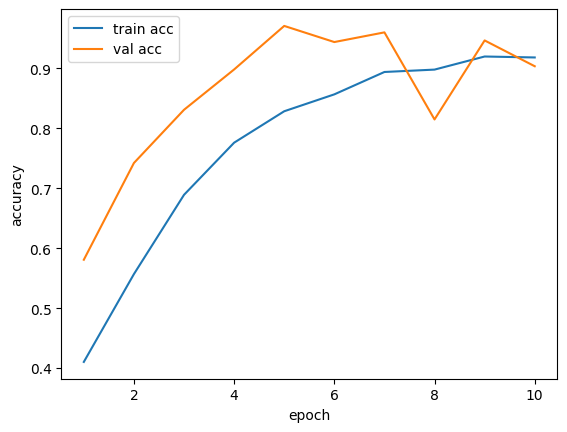

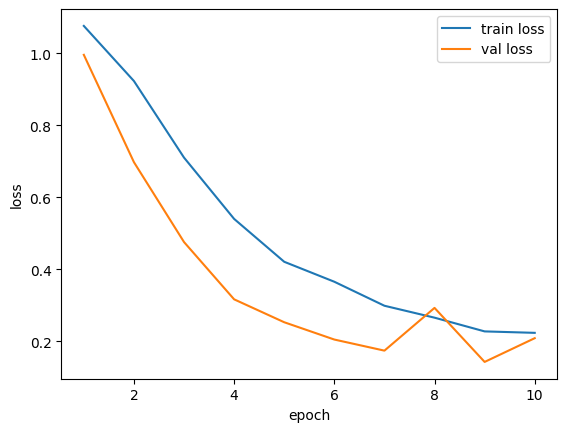

In [11]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label="train acc")
plt.plot(epochs, val_acc, label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

## 12- Évaluer + charger le meilleur modèle

On recharge le modèle qui a obtenu les meilleures performances pendant l’entraînement.
On l’évalue sur les données de validation pour mesurer sa précision finale.
Cela permet d’avoir une estimation réaliste de la performance du modèle.
C’est le modèle qu’on utilisera pour faire des prédictions.

In [12]:
best_model = tf.keras.models.load_model(best_path)
test_loss, test_acc = best_model.evaluate(val_ds, verbose=0)
print("val loss:", test_loss)
print("val acc :", test_acc)

val loss: 0.25336650013923645
val acc : 0.9704301357269287


In [28]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(path: str):
    img = load_img(path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)  # batch 1
    preds = best_model.predict(x, verbose=0)[0]
    idx = int(np.argmax(preds))
    print("Pred:", class_names[idx], "probas:", preds)

# Exemple: mets une image dans le dossier du projet et donne son chemin:
predict_image("test/r.jpg") # vrai = rock
predict_image("test/p.jpg") # vrai = paper
predict_image("test/s.jpg") # vrai = scissors

Pred: rock probas: [0.02872683 0.94823617 0.02303699]
Pred: paper probas: [0.67822886 0.27038616 0.05138496]
Pred: scissors probas: [0.01477988 0.4529053  0.53231484]
